In [1]:
import pandas as pd

df = pd.read_csv("../data/students.csv")

df

,study_hours,attendance,previous_score,assignments,sleep_hours,final_score
0,2,60,50,5,6,52
1,3,65,55,6,6,58
2,4,70,60,6,7,63
3,5,75,65,7,7,69
4,6,80,70,8,7,75
5,7,85,75,8,8,81
6,8,88,80,9,8,86
7,9,92,85,9,8,91
8,10,95,90,10,9,96
9,4,68,58,6,6,61


In [2]:
df.shape

(12, 6)

In [3]:
df.columns


Index(['study_hours', 'attendance', 'previous_score', 'assignments',
       'sleep_hours', 'final_score'],
      dtype='str')

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   study_hours     12 non-null     int64
 1   attendance      12 non-null     int64
 2   previous_score  12 non-null     int64
 3   assignments     12 non-null     int64
 4   sleep_hours     12 non-null     int64
 5   final_score     12 non-null     int64
dtypes: int64(6)
memory usage: 708.0 bytes


In [5]:
df.isnull().sum()

study_hours       0
attendance        0
previous_score    0
assignments       0
sleep_hours       0
final_score       0
dtype: int64

In [6]:
df.describe()

,study_hours,attendance,previous_score,assignments,sleep_hours,final_score
count,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000
mean,6.000000,79.166667,70.333333,7.583333,7.250000,74.750000
std,2.486326,11.471968,12.942764,1.564279,0.965307,14.207073
min,2.000000,60.000000,50.000000,5.000000,6.000000,52.000000
25%,4.000000,69.500000,59.500000,6.000000,6.750000,62.500000
50%,6.000000,81.000000,71.000000,8.000000,7.000000,76.000000
75%,8.000000,88.500000,81.000000,9.000000,8.000000,86.500000
max,10.000000,95.000000,90.000000,10.000000,9.000000,96.000000


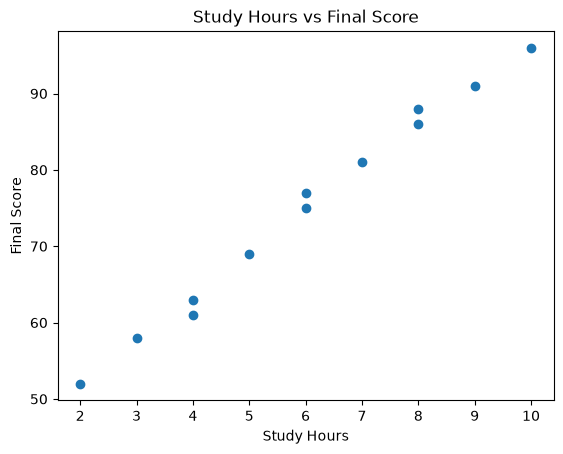

In [7]:
import matplotlib.pyplot as plt

plt.scatter(df["study_hours"], df["final_score"])

plt.xlabel("Study Hours")
plt.ylabel("Final Score")
plt.title("Study Hours vs Final Score")

plt.show()

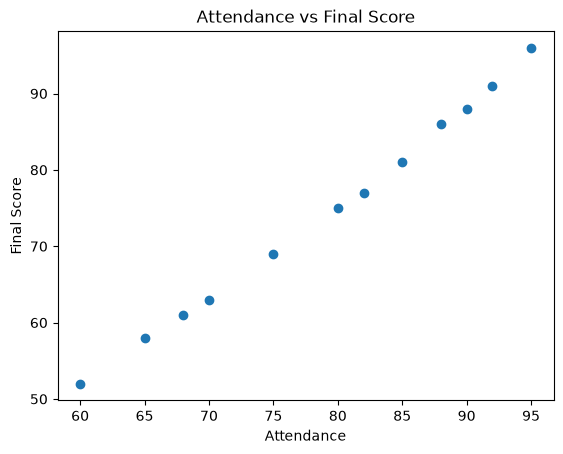

In [8]:
plt.scatter(df["attendance"], df["final_score"])

plt.xlabel("Attendance")
plt.ylabel("Final Score")
plt.title("Attendance vs Final Score")

plt.show()

In [9]:
X = df[[
    "study_hours",
    "attendance",
    "previous_score",
    "assignments",
    "sleep_hours"
]]

X

,study_hours,attendance,previous_score,assignments,sleep_hours
0,2,60,50,5,6
1,3,65,55,6,6
2,4,70,60,6,7
3,5,75,65,7,7
4,6,80,70,8,7
5,7,85,75,8,8
6,8,88,80,9,8
7,9,92,85,9,8
8,10,95,90,10,9
9,4,68,58,6,6


In [10]:
y = df["final_score"]

y

0     52
1     58
2     63
3     69
4     75
5     81
6     86
7     91
8     96
9     61
10    77
11    88
Name: final_score, dtype: int64

In [11]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (12, 5)
y shape: (12,)


In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (9, 5)
X_test: (3, 5)
y_train: (9,)
y_test: (3,)


In [15]:
from sklearn.linear_model import LinearRegression

In [16]:
model = LinearRegression()

In [17]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 1.8 , 0.45, 0.31, 0.47,-0.1 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['study_hours','attendance','previous_score','assignments','sleep_hours']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.145
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [18]:
predictions = model.predict(X_test)

In [19]:
predictions

array([76.76117318, 61.76536313, 51.66480447])

In [20]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

results

,Actual,Predicted
0,77,76.761173
1,61,61.765363
2,52,51.664804


In [21]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 0.44646182495344294


In [22]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 4.1452513966480495
Coefficients: [ 1.80027933  0.44553073  0.30865922  0.46648045 -0.09636872]


In [23]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

feature_importance

,Feature,Coefficient
0,study_hours,1.800279
1,attendance,0.445531
2,previous_score,0.308659
3,assignments,0.466480
4,sleep_hours,-0.096369


In [24]:
new_student = [[
    7,    # study hours
    85,   # attendance
    75,   # previous score
    8,    # assignments
    8     # sleep hours
]]

prediction = model.predict(new_student)

print("Predicted Final Score:", prediction[0])

Predicted Final Score: 80.72765363128491


c:\Users\Kishore\OneDrive\Desktop\student-performance-predicator\venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [25]:
import joblib

joblib.dump(model, "../models/student_model.pkl")

print("Model saved successfully!")

Model saved successfully!
